# Match movie segments to preprocessed eye-tracking data

This notebook retains the original procedure: each target timestamp defines a 3-second window (1.5 seconds before and after), matching rows are labelled with a segment ID and target image, and the updated eye-tracking table is saved.

Two compatibility corrections are necessary for the current files:

1. Annotation filenames are converted to part codes `01` and `02`, matching the `movie_part` values in the preprocessed files.
2. Annotation timestamps restart at zero within each movie part, so matching uses `part_timestamp`. The merged `timestamp` includes the duration of part 1 as an offset for part 2.

The exclusions supplied for this analysis are applied at both the movie-part and global segment levels. There are different exclusions for the main study and control study. In the witness movie numbering exception (starting from seg_34) is retained as an explicit matching-to-behavioral crosswalk.

In [16]:
from pathlib import Path
import pandas as pd

ANNOTATION_DIR = Path(
    "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/"
    "segments_movie_annotations"
)
FILTERED_ROOT = Path(
    "/Users/olgagulka/Desktop/IBS/2AFC_STUDY/preprocessing/results/"
    "eye_tracking_filtered_qc"
)
OUTPUT_DIR = Path(
    "/Users/olgagulka/Desktop/IBS/2AFC_STUDY/preprocessing/results/"
    "eye_tracking_with_matched_movie_seg"
)

TIME_WINDOW = 1.5

# Movie parts excluded from all further analyses.
EXCLUDED_PARTS = {
    ("sub_02", "witness", "02"),
    ("sub_04", "guest", "02"),
    ("sub_04", "witness", "01"),
    ("sub_04", "witness", "02"),
    ("sub_11", "guest", "01"),
    ("sub_11", "guest", "02"),
    ("sub_11", "sprout", "01"),
    ("sub_13", "prayer", "01"),
    ("sub_14", "witness", "02"),
    ("sub_15", "guest", "02"),
    ("sub_15", "witness", "01"),
    ("sub_15", "witness", "02"),
    ("sub_21", "prayer", "01"),
    ("sub_24", "witness", "02"),
    ("sub_25", "prayer", "01"),
}

# Target-centered segments excluded across every participant.
EXCLUDED_SEGMENTS = {
    ("sprout", "seg_26"),
    ("prayer", "seg_22"),
}

# Previous-study witness crosswalk:
# movie-matching seg_34 uses frame_35_witness.jpg, but it corresponds to
# frame_34_witness.jpg in the behavioral task numbering.
BEHAVIORAL_TARGET_OVERRIDES = {
    ("witness", "seg_34"): "frame_34_witness.jpg",
}

print(f"Recorded {len(EXCLUDED_PARTS)} excluded participant/movie parts.")
print(f"Recorded {len(EXCLUDED_SEGMENTS)} globally excluded movie segments.")

Recorded 15 excluded participant/movie parts.
Recorded 2 globally excluded movie segments.


## Check the individual part-file paths

These are the two paths from the original code. They are correctly formed for the preprocessing output. They are shown for verification but are not loaded by the matching function, which uses the merged movie file.

In [17]:
participant_id = "sub_01"
movie = "witness"
movie_id_1 = "witness_part_01"
movie_id_2 = "witness_part_02"

eye_tracking_path = (
    FILTERED_ROOT / participant_id / movie
    / f"{movie_id_1}_{participant_id}_filtered_eye_data.csv"
)
eye_tracking_path_2 = (
    FILTERED_ROOT / participant_id / movie
    / f"{movie_id_2}_{participant_id}_filtered_eye_data.csv"
)

print(eye_tracking_path, "exists:", eye_tracking_path.exists())
print(eye_tracking_path_2, "exists:", eye_tracking_path_2.exists())

/Users/olgagulka/Desktop/IBS/2AFC_STUDY/preprocessing/results/eye_tracking_filtered_qc/sub_01/witness/witness_part_01_sub_01_filtered_eye_data.csv exists: True
/Users/olgagulka/Desktop/IBS/2AFC_STUDY/preprocessing/results/eye_tracking_filtered_qc/sub_01/witness/witness_part_02_sub_01_filtered_eye_data.csv exists: True


## Matching function

The function keeps the original row-by-row assignment. It prints a warning if two 3-second windows overlap because a single `segment_id` column can hold only one label; consistent with the original logic, the later segment overwrites the earlier label in the overlap. `target_image` retains the image used to obtain the movie timestamp. `behavioral_target_image` stores the corresponding behavioral-task stimulus name, including the witness `seg_34` exception.

In [18]:
def match_movie_segments_to_eye_tracking(
    movie, participant_id, output_file, movie_part=None
):
    """
    Match movie segments (timestamps ±1.5 s) to eye-tracking data
    and save a new dataset with segment identifiers.

    Parameters
    ----------
    movie : str
        One of: guest, prayer, sprout, witness.
    participant_id : str
        Participant ID such as sub_01.
    output_file : str or pathlib.Path
        Full path for the output CSV.
    movie_part : str or int, optional
        Use 01 or 02 to load one individual part. When None, load the merged file.
    """
    movie = movie.lower()
    participant_id = participant_id.lower()

    # Load movie segments (with matching timestamps in seconds).
    movie_segments_path = ANNOTATION_DIR / f"annotations_{movie}_movie.csv"
    if not movie_segments_path.exists():
        raise FileNotFoundError(f"Movie-segment file not found: {movie_segments_path}")
    movie_segments = pd.read_csv(movie_segments_path)

    if movie_part is None:
        # Use both parts from the merged file.
        eye_tracking_file = (
            FILTERED_ROOT / participant_id / movie
            / f"{movie}_{participant_id}_merged_eye_data.csv"
        )
    else:
        # Use only one individual movie part.
        movie_part = f"{int(movie_part):02d}"
        eye_tracking_file = (
            FILTERED_ROOT / participant_id / movie
            / f"{movie}_part_{movie_part}_{participant_id}_filtered_eye_data.csv"
        )
    if not eye_tracking_file.exists():
        raise FileNotFoundError(
            f"Eye-tracking input file not found: {eye_tracking_file}"
        )
    eye_tracking_df = pd.read_csv(
        eye_tracking_file, dtype={"movie_part": "string"}
    )

    required_segment_columns = {"movie_part", "target_image", "match_timestamp_sec"}
    missing_segment_columns = required_segment_columns.difference(movie_segments.columns)
    if missing_segment_columns:
        raise ValueError(
            f"{movie_segments_path} is missing columns: {sorted(missing_segment_columns)}"
        )

    required_eye_columns = {"movie_part", "part_timestamp"}
    missing_eye_columns = required_eye_columns.difference(eye_tracking_df.columns)
    if missing_eye_columns:
        raise ValueError(
            f"{eye_tracking_file} is missing columns: {sorted(missing_eye_columns)}"
        )

    # Convert annotation names such as:
    #   sprout_part_01_NoCal.mp4 -> 01
    #   NO_CAL_GUEST_part01.mp4  -> 01
    # This matches the 01/02 part codes stored in the preprocessed eye data.
    movie_segments["mapped_part"] = (
        movie_segments["movie_part"]
        .astype("string")
        .str.extract(r"(?i)part[_-]?0*([12])", expand=False)
        .str.zfill(2)
    )

    # Ensure that values read as 1/2 or 01/02 have the same representation.
    eye_tracking_df["movie_part"] = (
        pd.to_numeric(eye_tracking_df["movie_part"], errors="coerce")
        .astype("Int64")
        .astype("string")
        .str.zfill(2)
    )

    # When one part is requested, filter BOTH tables inside this block.
    # Do not reset movie_segments' index: i + 1 must retain the original
    # whole-movie segment number (for example, guest part 2 starts at seg_21).
    if movie_part is not None:
        movie_segments = movie_segments.loc[
            movie_segments["mapped_part"] == movie_part
        ].copy()
        eye_tracking_df = eye_tracking_df.loc[
            eye_tracking_df["movie_part"] == movie_part
        ].copy()
        print(
            f"Processing only {participant_id} {movie} part {movie_part}: "
            f"{len(movie_segments)} target segments."
        )

    # Add new columns.
    eye_tracking_df["segment_id"] = None
    eye_tracking_df["target_image"] = None
    eye_tracking_df["behavioral_target_image"] = None

    time_window = TIME_WINDOW

    # Loop row by row, as in the original procedure.
    for i, row in movie_segments.iterrows():
        ts = row["match_timestamp_sec"]
        target_img = row["target_image"]
        part = row["mapped_part"]
        segment_id = f"seg_{i + 1}"

        if pd.isna(part):
            print(f"Warning: movie_part {row['movie_part']} not found in mapping.")
            continue

        if (movie, segment_id) in EXCLUDED_SEGMENTS:
            print(
                f"Excluded across all participants: {movie} {segment_id} "
                f"({target_img}); no rows were assigned."
            )
            continue

        if (participant_id, movie, part) in EXCLUDED_PARTS:
            print(
                f"Excluded: {participant_id} {movie} part {part}; "
                f"segment {i + 1} ({target_img}) was not assigned."
            )
            continue

        start, end = ts - time_window, ts + time_window
        mask = (
            (eye_tracking_df["part_timestamp"] >= start)
            & (eye_tracking_df["part_timestamp"] <= end)
            & (eye_tracking_df["movie_part"] == part)
        )

        # A row can belong to only one segment in this wide-table representation.
        overlap_rows = mask & eye_tracking_df["segment_id"].notna()
        if overlap_rows.any():
            print(
                f"  OVERLAP WARNING: segment {i + 1} overlaps "
                f"{int(overlap_rows.sum())} previously assigned rows; "
                "the later segment label will overwrite them."
            )

        # Assign values.
        behavioral_target_img = BEHAVIORAL_TARGET_OVERRIDES.get(
            (movie, segment_id), target_img
        )
        if behavioral_target_img != target_img:
            print(
                f"  BEHAVIORAL CROSSWALK: {movie} {segment_id} uses "
                f"{target_img} for movie matching and corresponds to "
                f"{behavioral_target_img} in the behavioral task."
            )
        eye_tracking_df.loc[mask, "segment_id"] = segment_id
        eye_tracking_df.loc[mask, "target_image"] = target_img
        eye_tracking_df.loc[mask, "behavioral_target_image"] = behavioral_target_img

        # Debug information.
        n_rows = int(mask.sum())
        print(
            f"Segment {i + 1} ({target_img}, part {part}): {n_rows} rows assigned "
            f"in window {start:.2f}–{end:.2f} sec"
        )

    # Save updated dataset.
    output_file = Path(output_file)
    output_file.parent.mkdir(parents=True, exist_ok=True)
    eye_tracking_df.to_csv(output_file, index=False)
    print(f"Updated eye-tracking data saved to {output_file}")
    print(f"Rows with a segment label: {eye_tracking_df['segment_id'].notna().sum()}")

    return eye_tracking_df

## Apply the function to one participant and movie

Set `movie_part` to `None` for a merged file, or to `"01"`/`"02"` for one individual part. The example below processes only the usable guest part 2 for `sub_12`.

In [10]:
movie = "witness"
participant_id = "sub_02"
movie_part = "01"

output_file = (
    OUTPUT_DIR
    / f"{movie}_part_{movie_part}_{participant_id}_eye_data_with_movie_segments.csv"
)

matched_eye_tracking = match_movie_segments_to_eye_tracking(
    movie=movie,
    participant_id=participant_id,
    movie_part=movie_part,
    output_file=output_file,
)

Processing only sub_02 witness part 01: 37 target segments.
Segment 1 (frame_01_witness.jpg, part 01): 182 rows assigned in window 26.61–29.61 sec
Segment 2 (frame_02_witness.jpg, part 01): 183 rows assigned in window 30.28–33.28 sec
Segment 3 (frame_03_witness.jpg, part 01): 183 rows assigned in window 38.50–41.50 sec
Segment 4 (frame_04_witness.jpg, part 01): 183 rows assigned in window 46.47–49.47 sec
Segment 5 (frame_05_witness.jpg, part 01): 183 rows assigned in window 50.43–53.43 sec
Segment 6 (frame_06_witness.jpg, part 01): 183 rows assigned in window 56.48–59.48 sec
Segment 7 (frame_07_witness.jpg, part 01): 183 rows assigned in window 72.16–75.16 sec
Segment 8 (frame_08_witness.jpg, part 01): 183 rows assigned in window 85.55–88.55 sec
Segment 9 (frame_09_witness.jpg, part 01): 183 rows assigned in window 128.43–131.43 sec
Segment 10 (frame_10_witness.jpg, part 01): 182 rows assigned in window 184.03–187.03 sec
Segment 11 (frame_11_witness.jpg, part 01): 183 rows assigned in 

## Matching eye tracking data with the movie segments that correspond to the task trial 

From each movie around 50 frames were extracted and were used as stimuli in the YN-2AFC tasks. Choosing hr 1.5sec window around where the frame occured in the movie for the further analysis.


In [19]:
movie = "witness"
batch_failures = []

for i in range(1, 33):
    participant_id = f"sub_{i:02d}"

    # Skip the complete participant/movie combination when both parts are excluded.
    excluded_parts = {
        part
        for pid, excluded_movie, part in EXCLUDED_PARTS
        if pid == participant_id and excluded_movie == movie
    }

    if excluded_parts == {"01", "02"}:
        print(
            f"SKIPPED {participant_id} {movie}: "
            "both movie parts are excluded."
        )
        continue

    output_file = (
        OUTPUT_DIR
        / f"{movie}_{participant_id}_merged_eye_data_with_movie_segments.csv"
    )

    try:
        matched_eye_tracking = match_movie_segments_to_eye_tracking(
            movie=movie,
            participant_id=participant_id,
            output_file=output_file,
            movie_part=None,
        )
    except FileNotFoundError as exc:
        print(f"SKIPPED {participant_id} {movie}: {exc}")
        batch_failures.append({
            "participant_id": participant_id,
            "movie": movie,
            "error": str(exc),
        })

print("\nBatch completed.")
print(f"Missing merged inputs: {len(batch_failures)}")

if batch_failures:
    display(pd.DataFrame(batch_failures))

Segment 1 (frame_01_witness.jpg, part 01): 183 rows assigned in window 26.61–29.61 sec
Segment 2 (frame_02_witness.jpg, part 01): 183 rows assigned in window 30.28–33.28 sec
Segment 3 (frame_03_witness.jpg, part 01): 183 rows assigned in window 38.50–41.50 sec
Segment 4 (frame_04_witness.jpg, part 01): 183 rows assigned in window 46.47–49.47 sec
Segment 5 (frame_05_witness.jpg, part 01): 183 rows assigned in window 50.43–53.43 sec
Segment 6 (frame_06_witness.jpg, part 01): 183 rows assigned in window 56.48–59.48 sec
Segment 7 (frame_07_witness.jpg, part 01): 183 rows assigned in window 72.16–75.16 sec
Segment 8 (frame_08_witness.jpg, part 01): 183 rows assigned in window 85.55–88.55 sec
Segment 9 (frame_09_witness.jpg, part 01): 183 rows assigned in window 128.43–131.43 sec
Segment 10 (frame_10_witness.jpg, part 01): 182 rows assigned in window 184.03–187.03 sec
Segment 11 (frame_11_witness.jpg, part 01): 183 rows assigned in window 195.00–198.00 sec
Segment 12 (frame_12_witness.jpg, p

,participant_id,movie,error
0,sub_02,witness,Eye-tracking input file not found: /Users/olga...
1,sub_14,witness,Eye-tracking input file not found: /Users/olga...
2,sub_24,witness,Eye-tracking input file not found: /Users/olga...


In [51]:
import itertools
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

## pearson correlation between each movie segment (this is later used for obtaining IGS and GS)

With `movie_part=None`, the function uses the merged file and processes both parts. With `movie_part="01"` or `movie_part="02"`, it loads that individual part file and matches only the annotations belonging to that part. Original whole-movie segment numbering is retained.

In [54]:
from pathlib import Path
import itertools
import numpy as np
import pandas as pd
from scipy.stats import pearsonr


CURRENT_PARTICIPANTS = [
    f"sub_{i:02d}" for i in range(1, 33)
]


# Participant/movie parts excluded from further analysis
EXCLUDED_PARTS = {
    ("sub_02", "witness", "02"),
    ("sub_04", "guest", "02"),
    ("sub_04", "witness", "01"),
    ("sub_04", "witness", "02"),
    ("sub_11", "guest", "01"),
    ("sub_11", "guest", "02"),
    ("sub_11", "sprout", "01"),
    ("sub_13", "prayer", "01"),
    ("sub_14", "witness", "02"),
    ("sub_15", "guest", "02"),
    ("sub_15", "witness", "01"),
    ("sub_15", "witness", "02"),
    ("sub_21", "prayer", "01"),
    ("sub_24", "witness", "02"),
    ("sub_25", "prayer", "01"),
    ("sub_28", "prayer", "01"),
    ("sub_28", "prayer", "02"),
    ("sub_31", "prayer", "01"),
    ("sub_31", "prayer", "02"),
}


# Segments rejected across all participants
DEFAULT_REJECT_SEGMENTS = {
    "guest": set(),
    "prayer": {"seg_22"},
    "sprout": {"seg_26"},
    "witness": set(),
}


def pearson_corr_per_segment(
    movie_name,
    participants=None,
    base_dir=(
        "/Users/olgagulka/Desktop/IBS/2AFC_STUDY/preprocessing/"
        "results/eye_tracking_with_matched_movie_seg"
    ),
    save_dir=(
        "/Users/olgagulka/Desktop/IBS/2AFC_STUDY/preprocessing/"
        "results/pear_correlation_between_segments"
    ),
    max_rows_per_segment=None,
    reject_segments=None,
):
    """
    Compute Pearson correlations for every participant pair and segment.

    When no merged file exists, available individual-part matched files
    are loaded instead.
    """
    movie_name = movie_name.lower()

    if participants is None:
        participants = CURRENT_PARTICIPANTS

    base_dir = Path(base_dir)
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    if reject_segments is None:
        rejected = DEFAULT_REJECT_SEGMENTS.get(movie_name, set()).copy()
    else:
        rejected = set(reject_segments)

    print(f"Movie: {movie_name}")
    print(f"Rejected segments: {sorted(rejected)}")

    data_dict = {}

    for participant_id in participants:
        merged_file = (
            base_dir
            / (
                f"{movie_name}_{participant_id}"
                "_merged_eye_data_with_movie_segments.csv"
            )
        )

        if merged_file.exists():
            input_files = [merged_file]
        else:
            # For participants who have only one usable movie part.
            input_files = sorted(
                base_dir.glob(
                    f"{movie_name}_part_*_{participant_id}"
                    "_eye_data_with_movie_segments.csv"
                )
            )

        if not input_files:
            print(
                f"Missing matched data: "
                f"{participant_id} {movie_name}"
            )
            continue

        participant_frames = []

        for input_file in input_files:
            df = pd.read_csv(
                input_file,
                dtype={"movie_part": "string"},
            )

            required_columns = {
                "movie_part",
                "part_timestamp",
                "segment_id",
                "x",
                "y",
            }

            missing_columns = required_columns.difference(df.columns)

            if missing_columns:
                raise KeyError(
                    f"{input_file} is missing columns: "
                    f"{sorted(missing_columns)}"
                )

            # Standardize movie part as 01 or 02.
            df["movie_part"] = (
                pd.to_numeric(
                    df["movie_part"],
                    errors="coerce",
                )
                .astype("Int64")
                .astype("string")
                .str.zfill(2)
            )

            # Remove excluded participant/movie parts.
            excluded_for_participant = {
                part
                for pid, excluded_movie, part in EXCLUDED_PARTS
                if (
                    pid == participant_id
                    and excluded_movie == movie_name
                )
            }

            if excluded_for_participant:
                df = df.loc[
                    ~df["movie_part"].isin(
                        excluded_for_participant
                    )
                ].copy()

            # Important: drop empty segment labels before converting to string.
            # Otherwise, missing labels become the false segment "nan".
            df = df.dropna(
                subset=[
                    "segment_id",
                    "part_timestamp",
                    "x",
                    "y",
                ]
            ).copy()

            df["segment_id"] = df["segment_id"].astype("string")

            for column in ["part_timestamp", "x", "y"]:
                df[column] = pd.to_numeric(
                    df[column],
                    errors="coerce",
                )

            df = df.dropna(
                subset=["part_timestamp", "x", "y"]
            )

            # Remove globally rejected movie segments.
            df = df.loc[
                ~df["segment_id"].isin(rejected)
            ].copy()

            if not df.empty:
                participant_frames.append(df)

        if not participant_frames:
            print(
                f"No usable segments after exclusions: "
                f"{participant_id} {movie_name}"
            )
            continue

        participant_df = pd.concat(
            participant_frames,
            ignore_index=True,
        )

        data_dict[participant_id] = participant_df

        print(
            f"Loaded {participant_id}: "
            f"{participant_df['segment_id'].nunique()} segments"
        )

    loaded_participants = sorted(data_dict)

    print(
        f"\nLoaded {len(loaded_participants)} participants: "
        f"{loaded_participants}"
    )

    pairs = list(
        itertools.combinations(loaded_participants, 2)
    )

    print(f"Participant pairs: {len(pairs)}")

    for participant_1, participant_2 in pairs:
        df1 = data_dict[participant_1]
        df2 = data_dict[participant_2]

        common_segments = (
            set(df1["segment_id"])
            .intersection(df2["segment_id"])
        )

        # Natural ordering: seg_1, seg_2, ..., seg_10
        segments = sorted(
            common_segments,
            key=lambda value: int(
                str(value).split("_")[-1]
            ),
        )

        results = []

        for segment_id in segments:
            segment_1 = (
                df1.loc[df1["segment_id"] == segment_id]
                .sort_values("part_timestamp")
            )

            segment_2 = (
                df2.loc[df2["segment_id"] == segment_id]
                .sort_values("part_timestamp")
            )

            minimum_length = min(
                len(segment_1),
                len(segment_2),
            )

            if max_rows_per_segment is not None:
                minimum_length = min(
                    minimum_length,
                    max_rows_per_segment,
                )

            if minimum_length < 2:
                continue

            x1 = segment_1["x"].to_numpy()[:minimum_length]
            y1 = segment_1["y"].to_numpy()[:minimum_length]

            x2 = segment_2["x"].to_numpy()[:minimum_length]
            y2 = segment_2["y"].to_numpy()[:minimum_length]

            vector_1 = np.concatenate([x1, y1])
            vector_2 = np.concatenate([x2, y2])

            try:
                result = pearsonr(vector_1, vector_2)
                correlation = result.statistic
                p_value = result.pvalue

            except Exception as error:
                print(
                    f"Correlation error: {participant_1}, "
                    f"{participant_2}, {segment_id}: {error}"
                )
                correlation = np.nan
                p_value = np.nan

            results.append({
                "movie": movie_name,
                "segment_id": segment_id,
                "participant_X": participant_1,
                "participant_Y": participant_2,
                "rows_used": minimum_length,
                "r": correlation,
                "p": p_value,
            })

        output_df = pd.DataFrame(results)

        output_path = (
            save_dir
            / (
                f"{movie_name}_correlation_"
                f"{participant_1}_{participant_2}.csv"
            )
        )

        output_df.to_csv(output_path, index=False)
        print(f"Saved: {output_path}")

    print(f"\nCompleted {movie_name}.")

In [55]:
pearson_corr_per_segment(
    movie_name="prayer",
    participants=CURRENT_PARTICIPANTS,
)



Movie: prayer
Rejected segments: ['seg_22']
Loaded sub_01: 53 segments
Loaded sub_02: 53 segments
Loaded sub_03: 53 segments
Loaded sub_04: 53 segments
Missing matched data: sub_05 prayer
Loaded sub_06: 53 segments
Loaded sub_07: 53 segments
Loaded sub_08: 53 segments
Loaded sub_09: 53 segments
Loaded sub_10: 53 segments
Loaded sub_11: 53 segments
Loaded sub_12: 53 segments
Missing matched data: sub_13 prayer
Loaded sub_14: 53 segments
Loaded sub_15: 53 segments
Loaded sub_16: 53 segments
Loaded sub_17: 53 segments
Loaded sub_18: 53 segments
Loaded sub_19: 53 segments
Loaded sub_20: 53 segments
Loaded sub_21: 30 segments


/var/folders/gt/k2rvby6d4yj9dn5qk0ts84_h0000gn/T/ipykernel_59528/401328155.py:115: DtypeWarning: Columns (22,23,24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


Loaded sub_22: 53 segments
Loaded sub_23: 53 segments
Loaded sub_24: 53 segments
Loaded sub_25: 30 segments
Loaded sub_26: 53 segments
Loaded sub_27: 53 segments
No usable segments after exclusions: sub_28 prayer
Loaded sub_29: 53 segments
Loaded sub_30: 53 segments
No usable segments after exclusions: sub_31 prayer
Loaded sub_32: 53 segments

Loaded 28 participants: ['sub_01', 'sub_02', 'sub_03', 'sub_04', 'sub_06', 'sub_07', 'sub_08', 'sub_09', 'sub_10', 'sub_11', 'sub_12', 'sub_14', 'sub_15', 'sub_16', 'sub_17', 'sub_18', 'sub_19', 'sub_20', 'sub_21', 'sub_22', 'sub_23', 'sub_24', 'sub_25', 'sub_26', 'sub_27', 'sub_29', 'sub_30', 'sub_32']
Participant pairs: 378
Saved: /Users/olgagulka/Desktop/IBS/2AFC_STUDY/preprocessing/results/pear_correlation_between_segments/prayer_correlation_sub_01_sub_02.csv
Saved: /Users/olgagulka/Desktop/IBS/2AFC_STUDY/preprocessing/results/pear_correlation_between_segments/prayer_correlation_sub_01_sub_03.csv
Saved: /Users/olgagulka/Desktop/IBS/2AFC_STUDY

In [14]:
pearson_corr_per_segment(
    movie_name="prayer",
    participants=CURRENT_PARTICIPANTS,
)


Movie: prayer
Rejected segments: ['seg_22']
Loaded sub_01: 53 segments
Loaded sub_02: 53 segments
Loaded sub_03: 53 segments
Loaded sub_04: 53 segments
Missing matched data: sub_05 prayer
Loaded sub_06: 53 segments
Loaded sub_07: 53 segments
Loaded sub_08: 53 segments
Loaded sub_09: 53 segments
Loaded sub_10: 53 segments
Loaded sub_11: 53 segments
Loaded sub_12: 53 segments
Missing matched data: sub_13 prayer
Loaded sub_14: 53 segments
Loaded sub_15: 53 segments
Loaded sub_16: 53 segments
Loaded sub_17: 53 segments
Loaded sub_18: 53 segments
Loaded sub_19: 53 segments
Loaded sub_20: 53 segments


/var/folders/gt/k2rvby6d4yj9dn5qk0ts84_h0000gn/T/ipykernel_59528/1521145072.py:111: DtypeWarning: Columns (22,23,24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


Loaded sub_21: 30 segments
Loaded sub_22: 53 segments
Loaded sub_23: 53 segments
Loaded sub_24: 53 segments
Loaded sub_25: 30 segments
Loaded sub_26: 53 segments
Loaded sub_27: 53 segments
Loaded sub_28: 53 segments
Loaded sub_29: 53 segments
Loaded sub_30: 53 segments
Loaded sub_31: 53 segments
Loaded sub_32: 53 segments

Loaded 30 participants: ['sub_01', 'sub_02', 'sub_03', 'sub_04', 'sub_06', 'sub_07', 'sub_08', 'sub_09', 'sub_10', 'sub_11', 'sub_12', 'sub_14', 'sub_15', 'sub_16', 'sub_17', 'sub_18', 'sub_19', 'sub_20', 'sub_21', 'sub_22', 'sub_23', 'sub_24', 'sub_25', 'sub_26', 'sub_27', 'sub_28', 'sub_29', 'sub_30', 'sub_31', 'sub_32']
Participant pairs: 435
Saved: /Users/olgagulka/Desktop/IBS/2AFC_STUDY/preprocessing/results/pear_correlation_between_segments/prayer_correlation_sub_01_sub_02.csv
Saved: /Users/olgagulka/Desktop/IBS/2AFC_STUDY/preprocessing/results/pear_correlation_between_segments/prayer_correlation_sub_01_sub_03.csv
Saved: /Users/olgagulka/Desktop/IBS/2AFC_STUDY/

In [ ]:
pearson_corr_per_segment(
    movie_name="prayer",
    participants=CURRENT_PARTICIPANTS,
)

Movie: guest
Rejected segments: []
Loaded sub_01: 30 segments


/var/folders/gt/k2rvby6d4yj9dn5qk0ts84_h0000gn/T/ipykernel_59528/1521145072.py:111: DtypeWarning: Columns (22,23,24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(
/var/folders/gt/k2rvby6d4yj9dn5qk0ts84_h0000gn/T/ipykernel_59528/1521145072.py:111: DtypeWarning: Columns (22,23,24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


Loaded sub_02: 30 segments
Loaded sub_03: 30 segments


/var/folders/gt/k2rvby6d4yj9dn5qk0ts84_h0000gn/T/ipykernel_59528/1521145072.py:111: DtypeWarning: Columns (22,23,24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(
/var/folders/gt/k2rvby6d4yj9dn5qk0ts84_h0000gn/T/ipykernel_59528/1521145072.py:111: DtypeWarning: Columns (22,23,24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


Loaded sub_04: 20 segments
Loaded sub_05: 30 segments


...

Loaded sub_28: 30 segments
Loaded sub_29: 30 segments


/var/folders/gt/k2rvby6d4yj9dn5qk0ts84_h0000gn/T/ipykernel_59528/1521145072.py:111: DtypeWarning: Columns (22,23,24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(
/var/folders/gt/k2rvby6d4yj9dn5qk0ts84_h0000gn/T/ipykernel_59528/1521145072.py:111: DtypeWarning: Columns (22,23,24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


Loaded sub_30: 30 segments
Loaded sub_31: 30 segments


/var/folders/gt/k2rvby6d4yj9dn5qk0ts84_h0000gn/T/ipykernel_59528/1521145072.py:111: DtypeWarning: Columns (22,23,24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


Loaded sub_32: 30 segments

Loaded 30 participants: ['sub_01', 'sub_02', 'sub_03', 'sub_04', 'sub_05', 'sub_06', 'sub_07', 'sub_08', 'sub_09', 'sub_10', 'sub_12', 'sub_13', 'sub_14', 'sub_16', 'sub_17', 'sub_18', 'sub_19', 'sub_20', 'sub_21', 'sub_22', 'sub_23', 'sub_24', 'sub_25', 'sub_26', 'sub_27', 'sub_28', 'sub_29', 'sub_30', 'sub_31', 'sub_32']
Participant pairs: 435
Saved: /Users/olgagulka/Desktop/IBS/2AFC_STUDY/preprocessing/results/pear_correlation_between_segments/guest_correlation_sub_01_sub_02.csv
Saved: /Users/olgagulka/Desktop/IBS/2AFC_STUDY/preprocessing/results/pear_correlation_between_segments/guest_correlation_sub_01_sub_03.csv
Saved: /Users/olgagulka/Desktop/IBS/2AFC_STUDY/preprocessing/results/pear_correlation_between_segments/guest_correlation_sub_01_sub_04.csv
Saved: /Users/olgagulka/Desktop/IBS/2AFC_STUDY/preprocessing/results/pear_correlation_between_segments/guest_correlation_sub_01_sub_05.csv
Saved: /Users/olgagulka/Desktop/IBS/2AFC_STUDY/preprocessing/results

In [37]:

#visualising the average correlation per segment
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_average_segment_correlations(
    movie_name,
    correlation_dir=(
        "/Users/olgagulka/Desktop/IBS/2AFC_STUDY/preprocessing/"
        "results/pear_correlation_between_segments"
    ),
):
    """
    Calculate and plot the average pairwise gaze correlation
    for every segment of one movie.
    """
    movie_name = movie_name.lower()
    correlation_dir = Path(correlation_dir)

    # Read only the pairwise participant files.
    correlation_files = sorted(
        correlation_dir.glob(
            f"{movie_name}_correlation_sub_*_sub_*.csv"
        )
    )

    if not correlation_files:
        raise FileNotFoundError(
            f"No pairwise correlation files found for {movie_name}"
        )

    all_correlations = []

    for file_path in correlation_files:
        df = pd.read_csv(file_path)

        required_columns = {
            "segment_id",
            "participant_X",
            "participant_Y",
            "r",
        }

        missing_columns = required_columns.difference(df.columns)

        if missing_columns:
            raise KeyError(
                f"{file_path} is missing columns: "
                f"{sorted(missing_columns)}"
            )

        all_correlations.append(df)

    correlations = pd.concat(
        all_correlations,
        ignore_index=True,
    )

    correlations["r"] = pd.to_numeric(
        correlations["r"],
        errors="coerce",
    )

    correlations = correlations.dropna(
        subset=["segment_id", "r"]
    ).copy()

    correlations = correlations.loc[
        np.isfinite(correlations["r"])
    ].copy()

    # Extract the numeric segment number from seg_1, seg_2, etc.
    correlations["segment_number"] = pd.to_numeric(
        correlations["segment_id"].str.extract(
            r"(\d+)$",
            expand=False,
        ),
        errors="coerce",
    )

    correlations = correlations.dropna(
        subset=["segment_number"]
    )

    correlations["segment_number"] = (
        correlations["segment_number"].astype(int)
    )

    # Fisher-z transformation before averaging correlations.
    correlations["fisher_z"] = np.arctanh(
        correlations["r"].clip(
            lower=-0.999999,
            upper=0.999999,
        )
    )

    summary = (
        correlations
        .groupby(
            ["segment_number", "segment_id"],
            as_index=False,
        )
        .agg(
            n_pairs=("r", "size"),
            mean_fisher_z=("fisher_z", "mean"),
            median_r=("r", "median"),
            q25_r=("r", lambda values: values.quantile(0.25)),
            q75_r=("r", lambda values: values.quantile(0.75)),
            minimum_r=("r", "min"),
            maximum_r=("r", "max"),
        )
        .sort_values("segment_number")
        .reset_index(drop=True)
    )

    # Transform the average back to Pearson r.
    summary["mean_r"] = np.tanh(
        summary["mean_fisher_z"]
    )

    summary = summary[
        [
            "segment_number",
            "segment_id",
            "n_pairs",
            "mean_r",
            "median_r",
            "q25_r",
            "q75_r",
            "minimum_r",
            "maximum_r",
        ]
    ]

    # Save the segment-level summary.
    summary_path = (
        correlation_dir
        / f"{movie_name}_average_correlation_by_segment.csv"
    )

    summary.to_csv(summary_path, index=False)

    # Add missing segment numbers as gaps in the plot.
    all_segment_numbers = range(
        summary["segment_number"].min(),
        summary["segment_number"].max() + 1,
    )

    plot_data = (
        summary
        .set_index("segment_number")
        .reindex(all_segment_numbers)
    )

    # Plot average correlation and the pairwise interquartile range.
    fig, ax = plt.subplots(figsize=(16, 6))

    ax.plot(
        plot_data.index,
        plot_data["mean_r"],
        marker="o",
        markersize=4,
        linewidth=1.5,
        color="darkblue",
        label="Fisher-averaged Pearson r",
    )

    ax.fill_between(
        plot_data.index,
        plot_data["q25_r"],
        plot_data["q75_r"],
        color="cornflowerblue",
        alpha=0.25,
        label="Pairwise interquartile range",
    )

    ax.axhline(
        0,
        color="black",
        linewidth=1,
        linestyle="--",
    )

    ax.set_ylim(-1, 1)

    ax.set_xlabel("Segment")
    ax.set_ylabel("Average pairwise Pearson correlation")

    ax.set_title(
        f"{movie_name.capitalize()}: "
        "average gaze correlation by segment"
    )

    ax.set_xticks(
        np.arange(
            summary["segment_number"].min(),
            summary["segment_number"].max() + 1,
            5,
        )
    )

    ax.grid(
        axis="y",
        alpha=0.25,
    )

    ax.legend()
    plt.tight_layout()
    plt.show()

    print(
        f"Loaded {len(correlation_files)} participant-pair files."
    )
    print(
        f"Calculated averages for {len(summary)} segments."
    )
    print(f"Summary saved to: {summary_path}")

    return summary

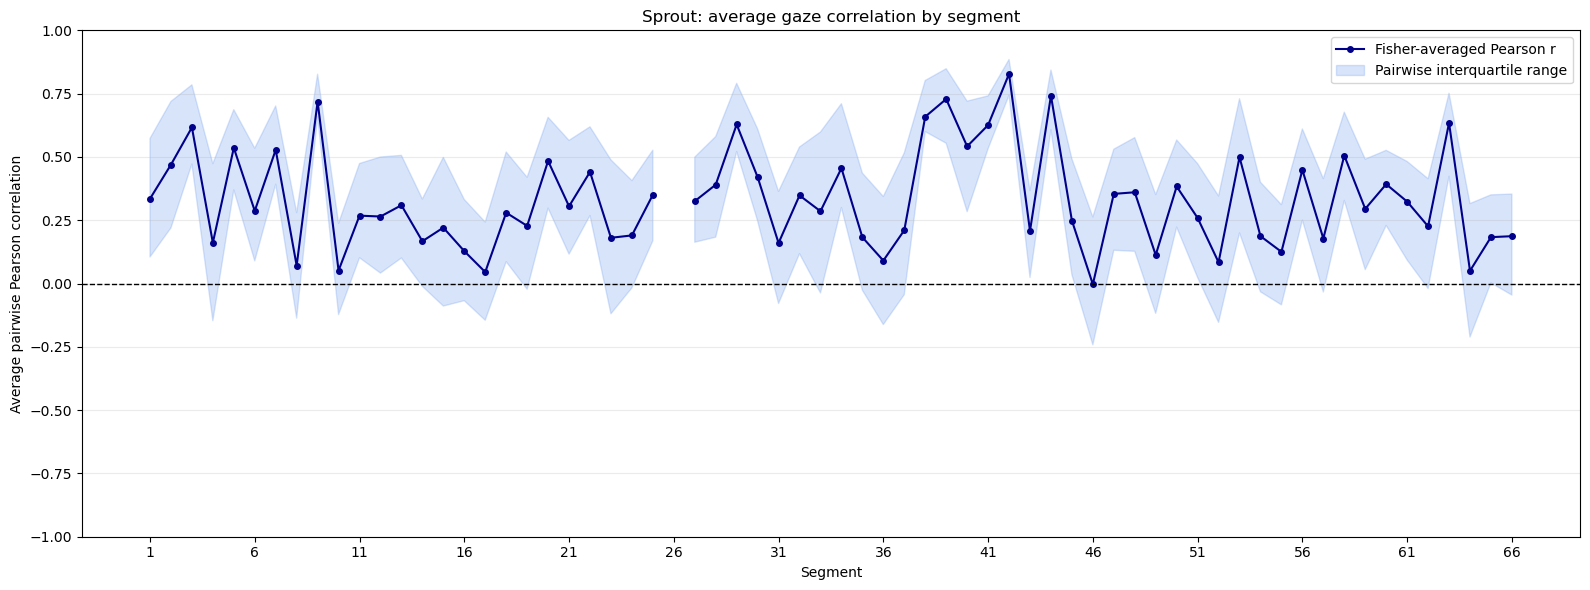

Loaded 496 participant-pair files.
Calculated averages for 65 segments.
Summary saved to: /Users/olgagulka/Desktop/IBS/2AFC_STUDY/preprocessing/results/pear_correlation_between_segments/sprout_average_correlation_by_segment.csv


,segment_number,segment_id,n_pairs,mean_r,median_r,q25_r,q75_r,minimum_r,maximum_r
0,1,seg_1,465,0.335,0.355,0.105,0.573,-0.912,0.927
1,2,seg_2,465,0.469,0.483,0.220,0.719,-0.972,0.950
2,3,seg_3,465,0.616,0.679,0.472,0.785,-0.841,0.972
3,4,seg_4,465,0.161,0.259,-0.147,0.473,-0.917,0.931
4,5,seg_5,465,0.536,0.555,0.370,0.687,-0.471,0.959
...,...,...,...,...,...,...,...,...,...
60,62,seg_62,496,0.226,0.244,-0.019,0.414,-0.655,0.973
61,63,seg_63,496,0.634,0.617,0.424,0.752,-0.017,0.970
62,64,seg_64,496,0.050,0.008,-0.211,0.316,-0.993,0.917
63,65,seg_65,496,0.183,0.184,0.003,0.350,-0.570,0.826


In [ ]:
sprout_average = plot_average_segment_correlations(
    movie_name="sprout"
)

display(
    sprout_average.round(3)
)

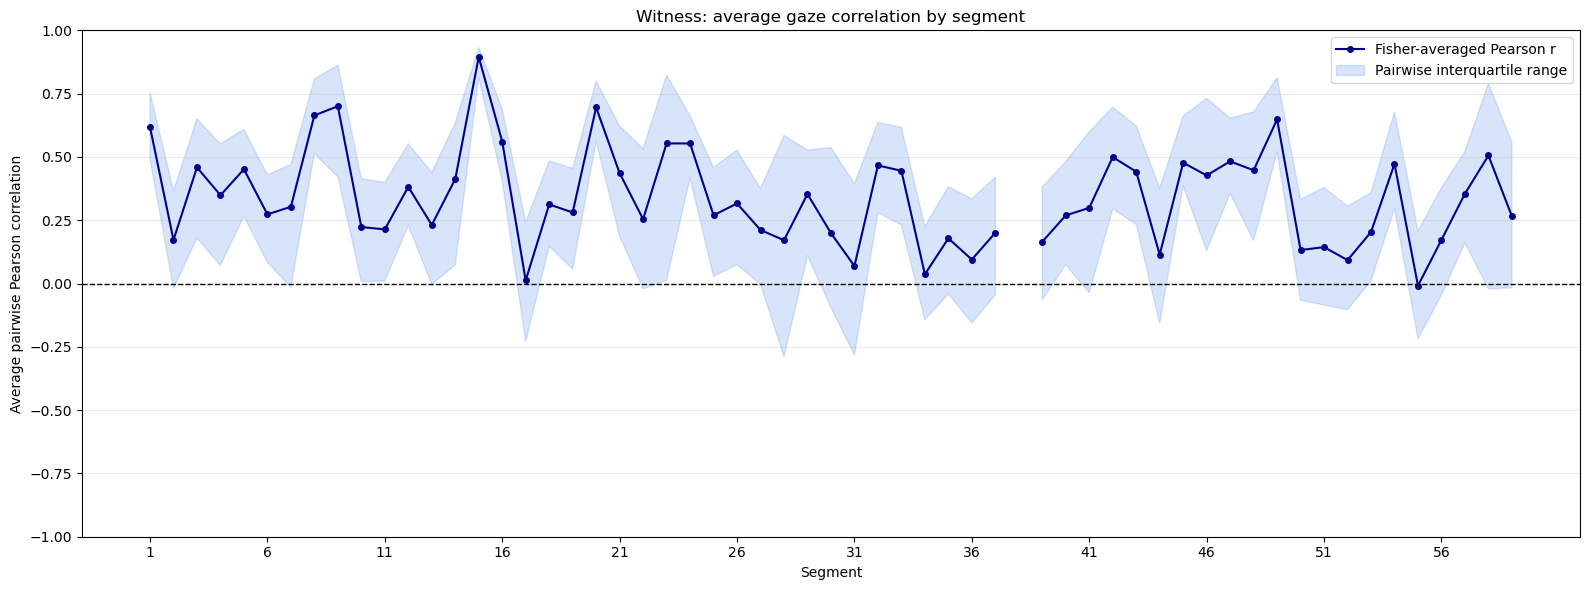

Loaded 378 participant-pair files.
Calculated averages for 58 segments.
Summary saved to: /Users/olgagulka/Desktop/IBS/2AFC_STUDY/preprocessing/results/pear_correlation_between_segments/witness_average_correlation_by_segment.csv


,segment_number,segment_id,n_pairs,mean_r,median_r,q25_r,q75_r,minimum_r,maximum_r
0,1,seg_1,378,0.618,0.653,0.492,0.754,-0.496,0.942
1,2,seg_2,378,0.172,0.179,-0.019,0.367,-0.670,0.805
2,3,seg_3,378,0.459,0.430,0.180,0.650,-0.434,0.940
3,4,seg_4,378,0.349,0.326,0.072,0.552,-0.472,0.956
4,5,seg_5,378,0.451,0.450,0.265,0.609,-0.468,0.841
5,6,seg_6,378,0.273,0.262,0.084,0.429,-0.344,0.823
6,7,seg_7,378,0.303,0.261,-0.014,0.470,-0.647,0.972
7,8,seg_8,378,0.664,0.688,0.513,0.808,-0.452,0.941
8,9,seg_9,378,0.700,0.689,0.422,0.863,-0.238,0.978
9,10,seg_10,378,0.223,0.226,0.008,0.414,-0.632,0.821


In [38]:
witness_average = plot_average_segment_correlations(
    movie_name="witness"
)

display(
    witness_average.round(3)
)

In [47]:
witness_average["median_r"].mean()

np.float64(0.3476179555176156)

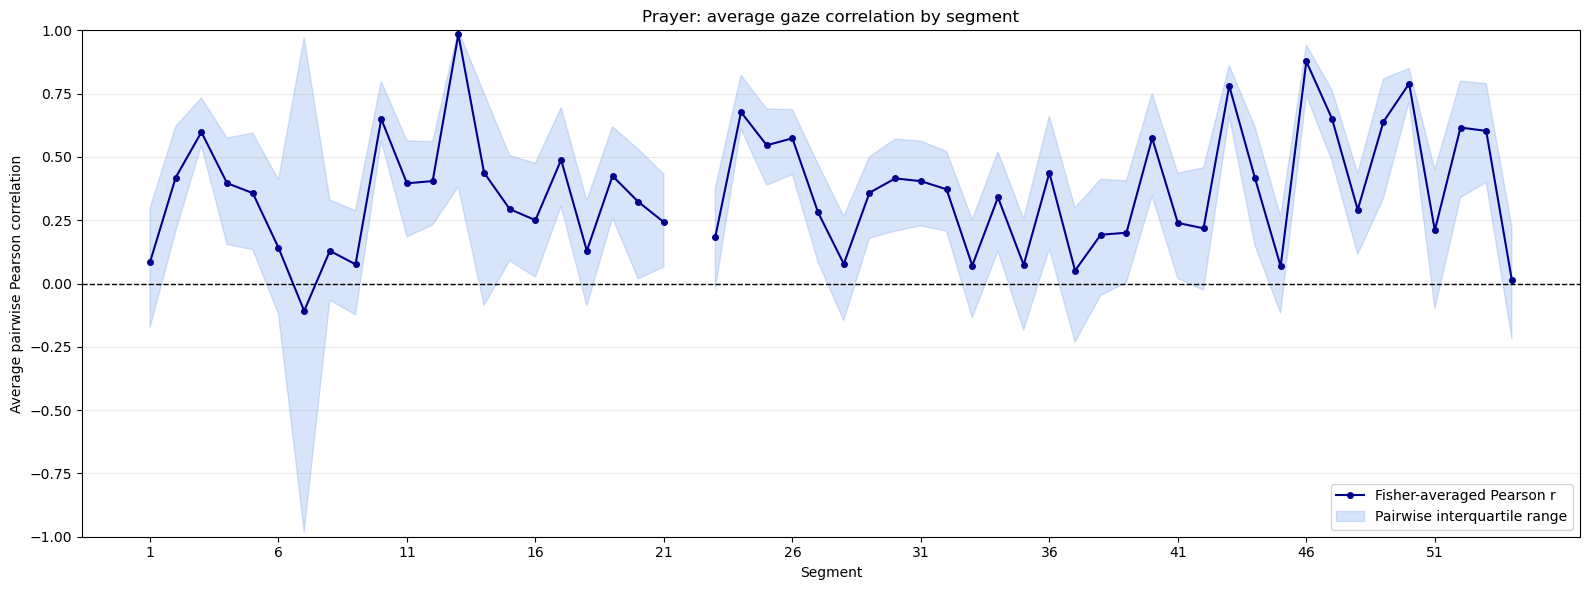

Loaded 435 participant-pair files.
Calculated averages for 53 segments.
Summary saved to: /Users/olgagulka/Desktop/IBS/2AFC_STUDY/preprocessing/results/pear_correlation_between_segments/prayer_average_correlation_by_segment.csv


,segment_number,segment_id,n_pairs,mean_r,median_r,q25_r,q75_r,minimum_r,maximum_r
0,1,seg_1,378,0.084,0.086,-0.175,0.296,-0.753,0.935
1,2,seg_2,378,0.419,0.446,0.206,0.620,-0.700,0.944
2,3,seg_3,378,0.598,0.655,0.546,0.733,-0.924,0.954
3,4,seg_4,378,0.396,0.330,0.154,0.575,-0.538,0.924
4,5,seg_5,378,0.357,0.432,0.134,0.594,-0.867,0.939
5,6,seg_6,378,0.141,0.173,-0.120,0.410,-0.773,0.847
6,7,seg_7,378,-0.108,-0.203,-0.981,0.971,-1.000,1.000
7,8,seg_8,378,0.129,0.147,-0.066,0.330,-0.884,0.781
8,9,seg_9,378,0.076,0.091,-0.124,0.288,-0.894,0.718
9,10,seg_10,378,0.650,0.705,0.564,0.799,-0.805,0.959


In [40]:
prayer_average = plot_average_segment_correlations(
    movie_name="prayer"
)

display(
    prayer_average.round(3)
)

In [46]:
witness_average["median_r"].mean()

np.float64(0.3476179555176156)

### Obtaining individual-to-group (IGS) and group-synchrony (GS) values per each movie segment

In [ ]:
CURRENT_PARTICIPANTS = [
    f"sub_{i:02d}" for i in range(1, 33)
]


# Participant/movie parts excluded from further analysis (control study)
EXCLUDED_PARTS = {
    ("sub_02", "witness", "02"),
    ("sub_04", "guest", "02"),
    ("sub_04", "witness", "01"),
    ("sub_04", "witness", "02"),
    ("sub_11", "guest", "01"),
    ("sub_11", "guest", "02"),
    ("sub_11", "sprout", "01"),
    ("sub_13", "prayer", "01"),
    ("sub_14", "witness", "02"),
    ("sub_15", "guest", "02"),
    ("sub_15", "witness", "01"),
    ("sub_15", "witness", "02"),
    ("sub_21", "prayer", "01"),
    ("sub_24", "witness", "02"),
    ("sub_25", "prayer", "01"),
    ("sub_28", "prayer", "01"),
    ("sub_28", "prayer", "02"),
    ("sub_31", "prayer", "01"),
    ("sub_31", "prayer", "02"),
}


In [ ]:
#obtaining IGS and GS synchrony per segment, and plotting the results 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob, os

def compute_group_and_pilot_sync(
    movie: str,
    participants: list,
    data_dir: str = "/Users/olgagulka/Desktop/IBS/2AFC_STUDY/preprocessing/results/pear_correlation_between_segments",
    output_dir_base: str = "/Users/olgagulka/Desktop/IBS/2AFC_STUDY/preprocessing/results/IGS_GS_synchrony",
    reject_segments: list = None,   # new argument
    plot: bool = True
):
    """
    Compute group average (leave-one-out) and pilot mean synchrony per segment,
    with an option to reject specific segments before averaging.

    Parameters
    ----------
    movie : str
        Movie name (e.g. 'witness', 'sprout', etc.)
    participants : list of str
        Participant IDs to include (e.g. ['pilot_07', 'pilot_08', ...])
    reject_segments : list of int, optional
        Segment numbers to exclude from synchrony computation.
    """

    pattern = os.path.join(data_dir, f"{movie}_correlation_*.csv")
    files = sorted(glob.glob(pattern))
    if not files:
        raise FileNotFoundError(f"No files matched {pattern}")

    dfs = []
    for f in files:
        df = pd.read_csv(f, sep=None, engine="python").rename(columns=str.strip)
        needed = {"segment_id", "participant_X", "participant_Y", "r"}
        missing = needed - set(df.columns)
        if missing:
            raise ValueError(f"{os.path.basename(f)} missing columns: {missing}")

        df["segment_id"] = df["segment_id"].astype(str)
        df["segment_num"] = (
            df["segment_id"].str.extract(r"(\d+)", expand=False)
            .astype(float)
            .astype("Int64")
        )
        df = df.dropna(subset=["segment_num"])
        df["segment_num"] = df["segment_num"].astype(int)
        dfs.append(df[["segment_id", "segment_num", "participant_X", "participant_Y", "r"]])

    pairs = pd.concat(dfs, ignore_index=True)
    pairs["r"] = pd.to_numeric(pairs["r"], errors="coerce")
    pairs = pairs.dropna(subset=["r", "segment_num"]).reset_index(drop=True)

    # --- Reject unwanted segments ---
    if reject_segments:
        before_n = pairs["segment_num"].nunique()
        pairs = pairs[~pairs["segment_num"].isin(reject_segments)]
        after_n = pairs["segment_num"].nunique()
        print(f"🗑 Rejected {before_n - after_n} segments: {reject_segments}")

    # --- Only keep pairs that include the specified participants ---
    pairs = pairs[pairs["participant_X"].isin(participants) & pairs["participant_Y"].isin(participants)]
    if pairs.empty:
        raise ValueError("No matching pairs found for the given participants.")

    # --- Pilot-level long format ---
    left = pairs[["segment_num", "participant_X", "r"]].rename(columns={"participant_X": "participant"})
    right = pairs[["segment_num", "participant_Y", "r"]].rename(columns={"participant_Y": "participant"})
    pilot_long = pd.concat([left, right], ignore_index=True)

    # --- Compute pilot mean per segment ---
    pilot_avg = (
        pilot_long.groupby(["segment_num", "participant"], as_index=False)["r"]
        .mean()
        .rename(columns={"r": "pilot_mean"})
    )
# --- Compute leave-one-out group mean per segment ---
    group_avg = []
    for seg, seg_pairs in pairs.groupby("segment_num"):
        for p in participants:
            mask = (
                (seg_pairs["participant_X"] != p) &
                (seg_pairs["participant_Y"] != p)
            )
            vals = seg_pairs.loc[mask, "r"]
            group_avg.append({
                "segment_num": seg,
                "participant": p,
                "group_mean": vals.mean() if len(vals) else np.nan
            })

    group_avg = pd.DataFrame(group_avg)


    # --- Merge results ---
    results = pilot_avg.merge(group_avg, on=["segment_num", "participant"], how="left")

    # --- Save results ---
    output_dir = os.path.join(output_dir_base, movie)
    os.makedirs(output_dir, exist_ok=True)
    output_path = os.path.join(output_dir, f"participants_sync_metrics_{movie}_final_all_subjects.csv")
    results.to_csv(output_path, index=False)
    print(f"✅ Saved synchrony metrics to: {output_path}")

    # --- Plot (optional) ---
    TITLE_SIZE = 30
    LABEL_SIZE = 25
    TICK_SIZE = 20
    LEGEND_SIZE = 20


    if plot:
        seg_order = np.sort(pairs["segment_num"].unique())
        fig, ax_left = plt.subplots(figsize=(12, 6))

        # Plot pilot mean
        for participant, sub in results.sort_values("segment_num").groupby("participant"):
            ax_left.plot(
                sub["segment_num"],
                sub["pilot_mean"],
                marker="o",
                linestyle="--",
                alpha=0.8,
                #label=f"{participant} (mean)"
            )

        # Group mean
        ax_right = ax_left.twinx()
        ga_sorted = results.groupby("segment_num", as_index=False)["group_mean"].mean()
        ax_right.plot(
            ga_sorted["segment_num"],
            ga_sorted["group_mean"],
            marker="s",
            linestyle="-",
            linewidth=3.5,
            color="black",
            label="Group mean (leave-one-out)"
        )

        ax_left.set_xlabel("Trial", fontsize=LABEL_SIZE)
        ax_left.set_ylabel("Synchrony (r)", fontsize=LABEL_SIZE)
        

        ax_left.grid(True, linestyle="--", alpha=0.6)
            #ax.left an right control number on the axes
        ax_left.tick_params(axis="both", labelsize=TICK_SIZE)
        ax_right.tick_params(axis="y", labelsize=TICK_SIZE)


        #h_left, l_left = ax_left.get_legend_handles_labels()
        #h_right, l_right = ax_right.get_legend_handles_labels()
        #ax_left.legend(h_left + h_right, l_left + l_right, bbox_to_anchor=(1.04, 1), loc="upper left"))

        plt.title(f"Inidividual vs. group synchrony per trial for {movie} movie", fontsize=TITLE_SIZE)
        plt.tight_layout()
        plt.show()

    return results


✅ Saved synchrony metrics to: /Users/olgagulka/Desktop/IBS/2AFC_STUDY/preprocessing/results/IGS_GS_synchrony/witness/participants_sync_metrics_witness_final_all_subjects.csv


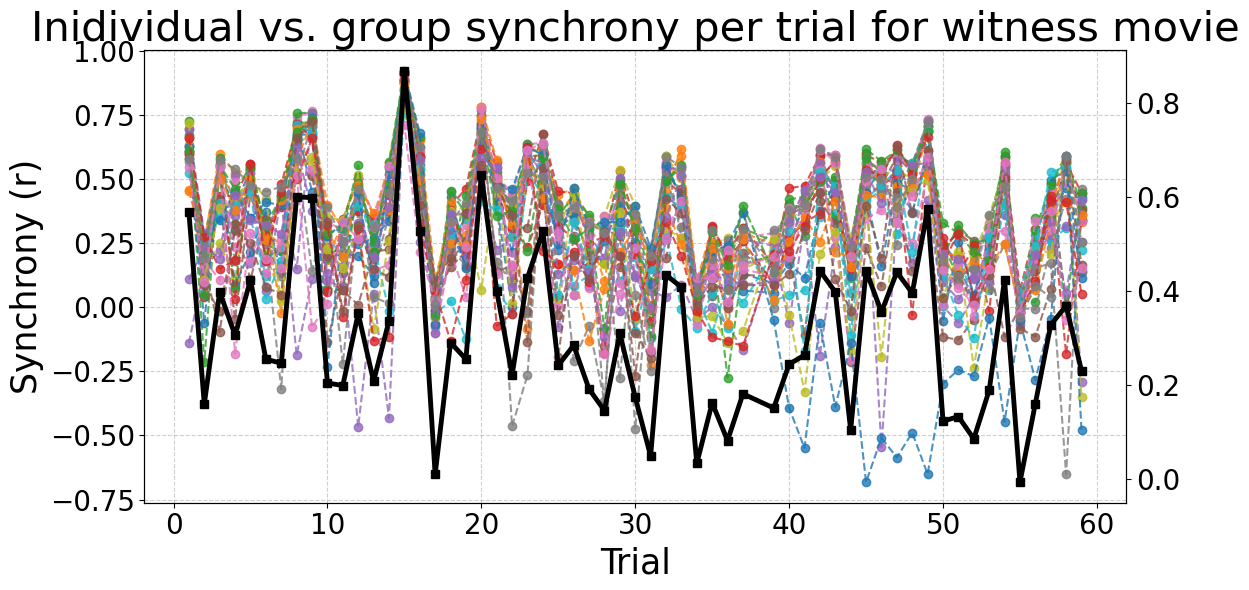

In [98]:
results = compute_group_and_pilot_sync(
    movie="witness",
    participants = CURRENT_PARTICIPANTS,
    reject_segments=[]

)


#from "guest" exclude pilot 15
#from prayer exclude: pilot_14   #and prayer reject segment: seg_22
# from witness exclude: pilot_16
# sprout reject segments: seg_26

In [99]:
movie = "witness"
df = pd.read_csv(f"/Users/olgagulka/Desktop/IBS/2AFC_STUDY/preprocessing/results/IGS_GS_synchrony/{movie}/participants_sync_metrics_{movie}_final_all_subjects.csv")

In [81]:
df

,segment_num,participant,pilot_mean,group_mean
0,1,sub_01,0.157376,0.081380
1,1,sub_02,0.042179,0.090980
2,1,sub_03,0.137979,0.082997
3,1,sub_04,0.047990,0.090496
4,1,sub_06,0.245888,0.074004
...,...,...,...,...
1433,54,sub_26,0.040519,0.030187
1434,54,sub_27,0.029454,0.031038
1435,54,sub_29,0.003601,0.033027
1436,54,sub_30,-0.190537,0.047961
